## <span style="color: aqua;">Part 3: Putting It All Together</span>

Welcome to the final notebook. Here we combine all cleaned data into a single SQLite 
database and conduct the full analysis. Before building out the database, we'll start 
with a relationship diagram outlining how the tables connect to one another.

##### **Please Review the Entity Relationship Diagram (ERD)!!** It is important to lay out how the data relates and how it should be organized. This ERD will be displayed in each section for reference.


![Tornado ERD](../Assets/Tornado_ERD.jpeg)

In [ ]:
# Before any coding begins, we need to import all needed libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sqlite3
import geopandas as gpd
import seaborn as sns
import geodatasets
from matplotlib.patches import Patch

os.makedirs('../Data/Tornado_SQL_database', exist_ok=True)
print(os.path.exists('../Data/Tornado_SQL_database'))

# Connect to (or create) the database using the conn variable 
conn = sqlite3.connect('../Data/Tornado_SQL_database/tornado_alley.db') # The cursor command lets us run commands to the connection crated above. You can't run SQL directly on the connection, hence the use of cursor.
cursor = conn.cursor()

# Creating tables // cursor.executescript() is the cursor performing the command to create multiple SQL statements at once.
cursor.executescript(""" 
    CREATE TABLE IF NOT EXISTS state_regions (
        state                  TEXT PRIMARY KEY,
        region_name            TEXT NOT NULL,
        is_eastern_shift_state INTEGER NOT NULL DEFAULT 0
    );

    CREATE TABLE IF NOT EXISTS fema_declarations (
        disaster_number  INTEGER PRIMARY KEY,
        state            TEXT NOT NULL,
        year             INTEGER NOT NULL,
        declaration_type TEXT NOT NULL,
        ia_declared      INTEGER NOT NULL DEFAULT 0,
        ih_declared      INTEGER NOT NULL DEFAULT 0,
        incident_type    TEXT NOT NULL
    );

    CREATE TABLE IF NOT EXISTS tornado_events (
        event_id          INTEGER PRIMARY KEY,
        state             TEXT NOT NULL,
        tor_f_scale       TEXT,
        tor_length        REAL,
        tor_width         REAL,
        fatalities        INTEGER NOT NULL,
        injuries          INTEGER NOT NULL,
        year              INTEGER NOT NULL
    );
""")

conn.commit() # SQL does not saves changes until they are commited.
print("Tables created successfully.")

True
Tables created successfully.


In [ ]:
# Load cleaned data from CSVs
tornado_df = pd.read_csv('../Data/Cleaned_Tornado_Data/tornado_all_years_cleaned.csv')
FEMA_df = pd.read_csv('../Data/Cleaned_FEMA_Data/FEMA_data_cleaned.csv')
state_regions_df = pd.read_csv('../Data/Cleaned_Tornado_Data/eastern_state_notation.csv')

# Connect to database
conn = sqlite3.connect('../Data/Tornado_SQL_database/tornado_alley.db')

# Load into SQL tables
state_regions_df.to_sql('state_regions', conn, if_exists='replace', index=False)
tornado_df.to_sql('tornado_events', conn, if_exists='replace', index=False)
FEMA_df.to_sql('fema_declarations', conn, if_exists='replace', index=False)

conn.commit()
print("Data loaded successfully.")

Data loaded successfully.


## <span style="color: aqua;">Main Question: Has Tornado Alley shifted eastward?</span>

With all the data in place, we can return to the central question of this project. The most 
direct way to approach it is to compare total tornado counts across the three state categories 
over each decade.

The data below shows that emerging states have seen a clear increase in tornado activity over 
time. However, the original Tornado Alley states continue to experience a substantial number 
of tornadoes. This points less to a geographic shift and more to an overall expansion — Tornado 
Alley isn't moving, it's growing.

In [ ]:
# Selecting year and region name AS tornado count from tornado events, joining the state table on state column, grouping by year.
pd.read_sql("""
    SELECT t.year, s.region_name, COUNT(*) as tornado_count 
    FROM tornado_events t
    JOIN state_regions s ON t.state = s.state
    GROUP BY t.year, s.region_name
    ORDER BY t.year
""", conn)

,year,region_name,tornado_count
0,2004,Emerging,617
1,2004,Other,550
2,2004,Traditional,780
3,2014,Emerging,412
4,2014,Other,265
5,2014,Traditional,387
6,2024,Emerging,911
7,2024,Other,412
8,2024,Traditional,806


## <span style="color: aqua;">Follow-up Question: Are tornadoes getting stronger in recent decades compared to previous decades?</span>

The data suggests yes — tornadoes in 2024 appear stronger in terms of both physical size and 
ground contact. This analysis looks at raw path measurements rather than EF scale ratings: 
specifically, how long a tornado stayed on the ground and how wide its damage path was, both 
measured in miles.

In [ ]:
# Selecting year and region name from tornado events, joining state regions table on state columns.
pd.read_sql("""
    SELECT t.year, s.region_name, 
           AVG(t.tor_length) as avg_length,
           AVG(t.tor_width) as avg_width
    FROM tornado_events t
    JOIN state_regions s ON t.state = s.state
    GROUP BY t.year, s.region_name
    ORDER BY t.year
""", conn)

,year,region_name,avg_length,avg_width
0,2004,Emerging,2.865478,0.058705
1,2004,Other,3.044727,0.044460
2,2004,Traditional,1.760641,0.062445
3,2014,Emerging,3.681262,0.120016
4,2014,Other,2.064000,0.066344
5,2014,Traditional,2.664160,0.103387
6,2024,Emerging,4.008332,0.138748
7,2024,Other,3.700097,0.088984
8,2024,Traditional,3.400918,0.116725


## <span style="color: aqua;">Follow-up Question: Are there more FEMA declarations in recent decades compared to years past?</span>

Here the data tells a more nuanced story. It's important to note that the FEMA dataset 
covers more than just tornadoes — it includes severe storms broadly. A storm can trigger 
a FEMA declaration through straight-line wind damage, flooding, or other impacts without 
ever producing a tornado. The spike in 2004 is likely tied to an unusually active severe 
weather season rather than a true surge in tornado activity, with non-tornado events 
inflating the declaration count.

That said, the overall upward trend in tornado activity from 2014 to 2024 remains consistent 
with the patterns observed earlier in this analysis.

In [ ]:
pd.read_sql("""
    SELECT f.year, s.region_name, COUNT(*) as declaration_count
    FROM fema_declarations f
    JOIN state_regions s ON f.state = s.state
    GROUP BY f.year, s.region_name
    ORDER BY f.year
""", conn)

,year,region_name,declaration_count
0,2004,Emerging,442
1,2004,Other,428
2,2004,Traditional,216
3,2014,Emerging,104
4,2014,Other,51
5,2014,Traditional,83
6,2024,Emerging,109
7,2024,Other,195
8,2024,Traditional,240


### <h2 style="color: lime;">Visual Evidence</h2>

While raw data can give clear evidence, it may not as easy to digest as a diagram outlining this information. At first, I attempted to place this information on a heat map to show tornado counts have grown per state.

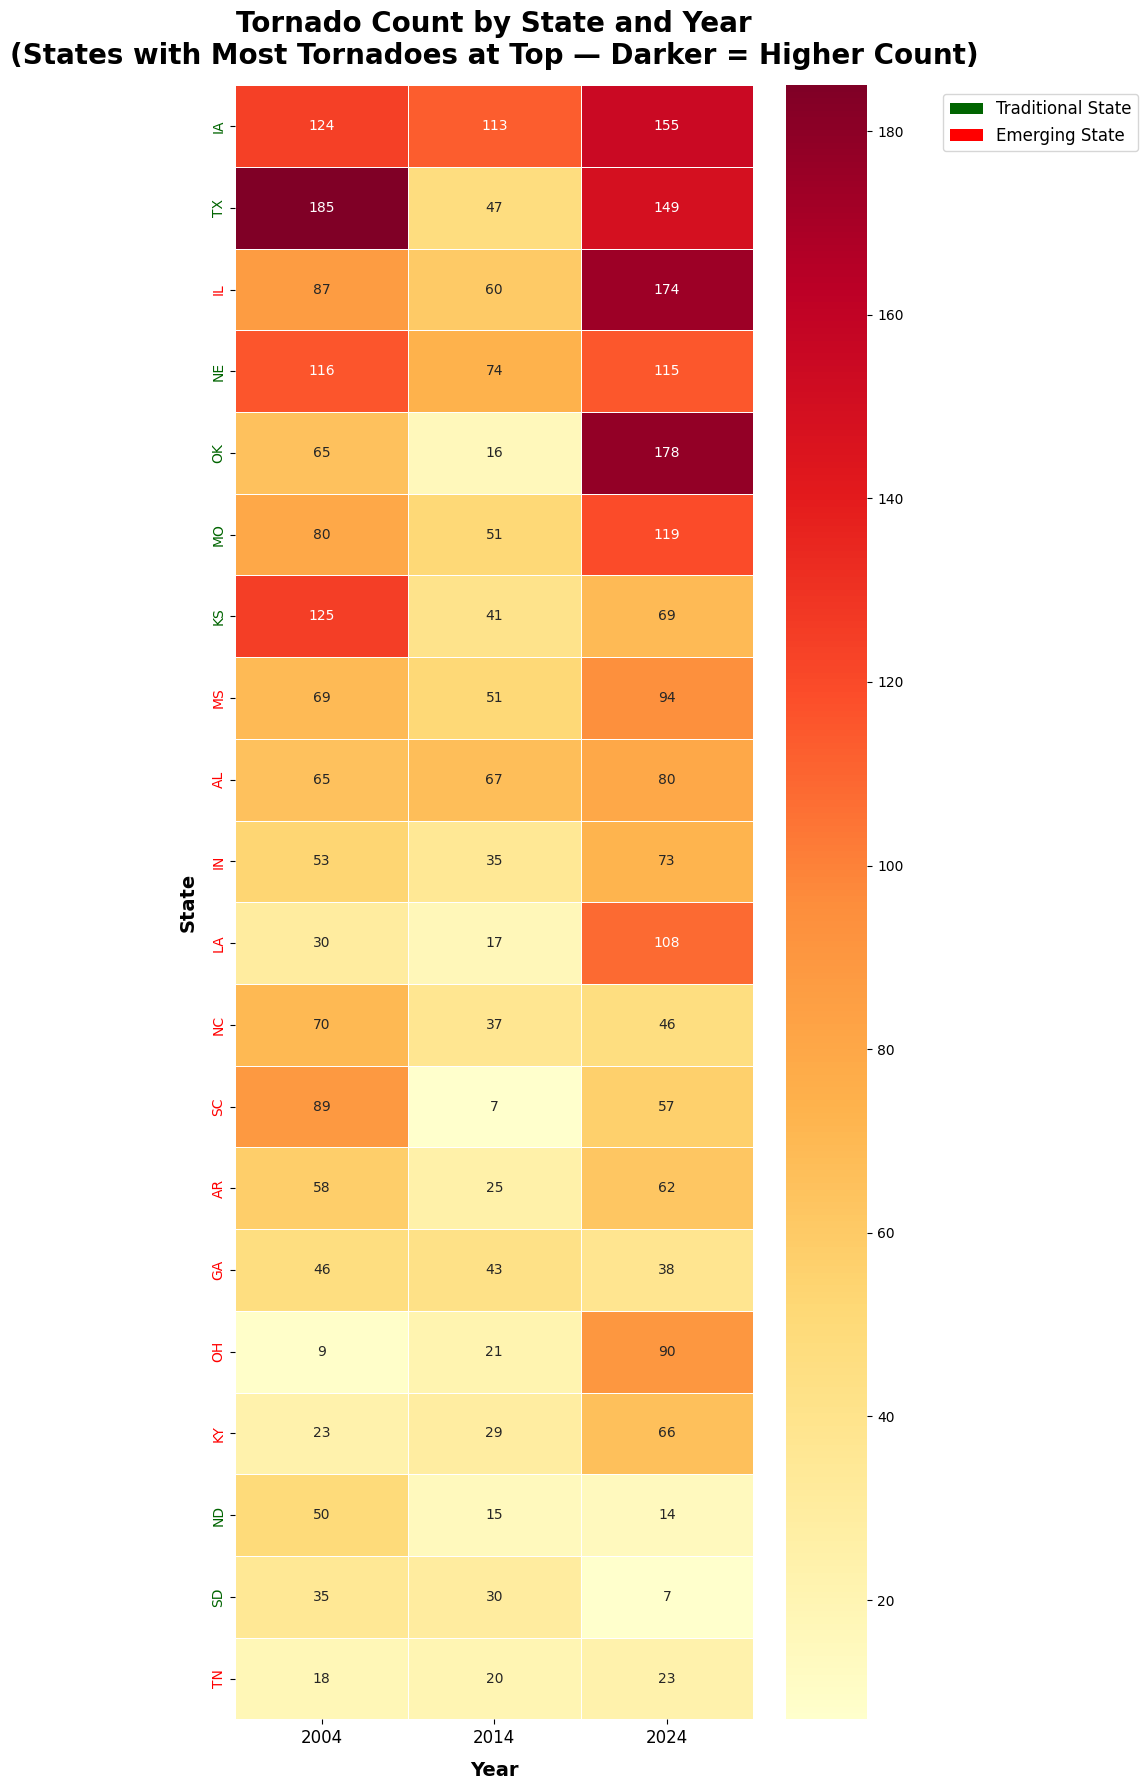

In [ ]:
# Query tornado count by state and year
heatmap_df = pd.read_sql("""
    SELECT t.state, t.year, COUNT(*) as tornado_count
    FROM tornado_events t
    JOIN state_regions s ON t.state = s.state
    WHERE s.region_name IN ('Traditional', 'Emerging')
    GROUP BY t.state, t.year
    ORDER BY t.year
""", conn)

# Pivot for heatmap format
heatmap_pivot = heatmap_df.pivot(index='state', columns='year', values='tornado_count').fillna(0)

# Sort by total tornado count so most active states are at the top
heatmap_pivot = heatmap_pivot.loc[heatmap_pivot.sum(axis=1).sort_values(ascending=False).index]

# Create region lookup
region_lookup = pd.read_sql("SELECT state, region_name FROM state_regions", conn)
region_dict = dict(zip(region_lookup['state'], region_lookup['region_name']))

fig, ax = plt.subplots(figsize=(10, 18))
sns.heatmap(
    heatmap_pivot,
    cmap='YlOrRd',
    linewidths=0.5,
    annot=True,
    fmt='.0f',
    ax=ax
)

# Color y-axis labels by region
for label in ax.get_yticklabels():
    state = label.get_text()
    if region_dict.get(state) == 'Traditional':
        label.set_color('darkgreen')
    elif region_dict.get(state) == 'Emerging':
        label.set_color('red')

# Legend
legend_elements = [Patch(facecolor='darkgreen', label='Traditional State'),
                   Patch(facecolor='red', label='Emerging State')]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.35, 1), loc='upper left', fontsize=12)

ax.set_title('Tornado Count by State and Year\n(States with Most Tornadoes at Top — Darker = Higher Count)', fontsize=20, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('State', fontsize=14, fontweight='bold', labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('../Graphs/heatmap_tornado_count.png', bbox_inches='tight', dpi=300)
plt.show()

The heatmap above works well for comparing raw counts — Illinois, for instance, shows a 
notable spike in tornado frequency. However, the format proved too large and cluttered to 
convey geographic trends clearly.

To better visualize the data, I used GeoPandas to plot tornado counts directly onto a map 
of the continental United States, with one map per decade to make growth or reduction easier 
to track. Alaska, Hawaii, and U.S. territories were excluded since they fall outside the 
scope of this analysis. While these regions load automatically from the GeoJSON source, they 
aren't relevant here.

In [ ]:
# Load US states GeoJSON
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
us_states = gpd.read_file(url)

exclude = ['Alaska', 'Hawaii', 'Puerto Rico', 'Guam', 
           'Virgin Islands', 'American Samoa', 'Northern Mariana Islands']
continental = us_states[~us_states['name'].isin(exclude)]

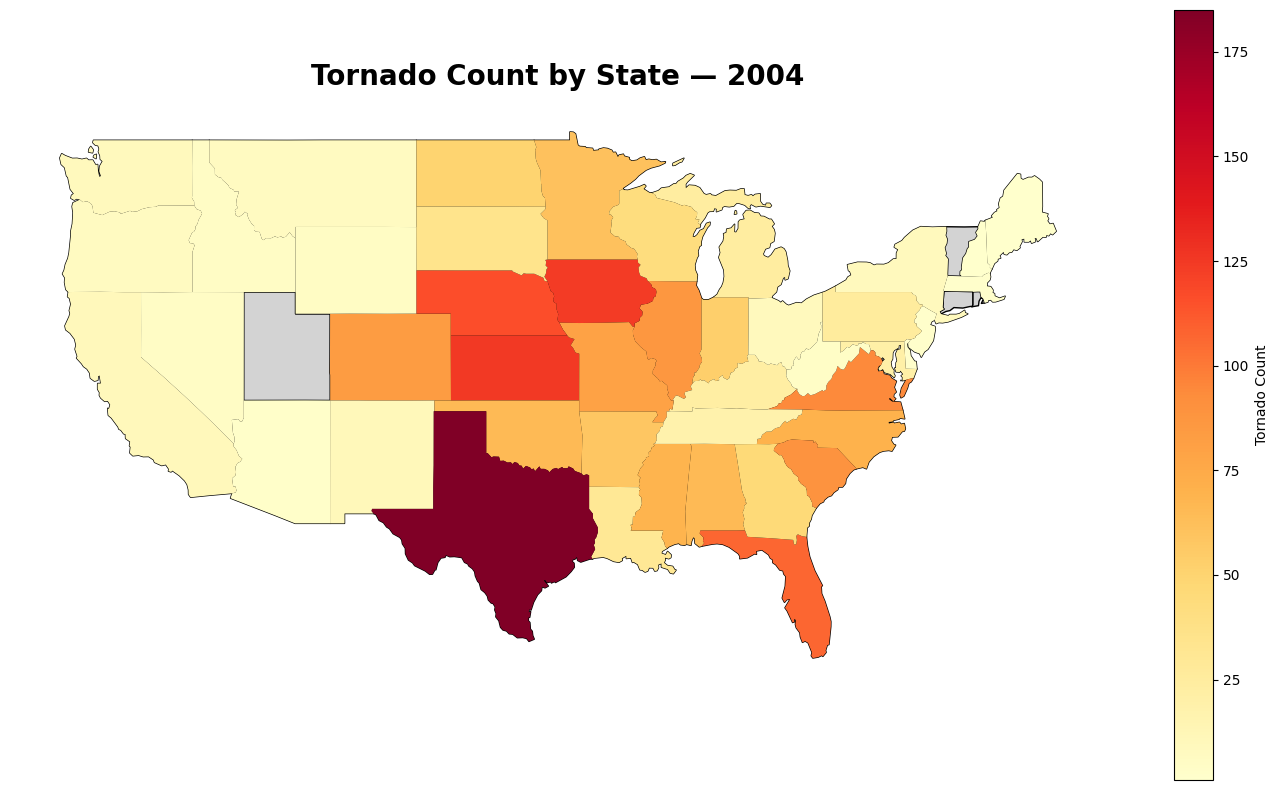

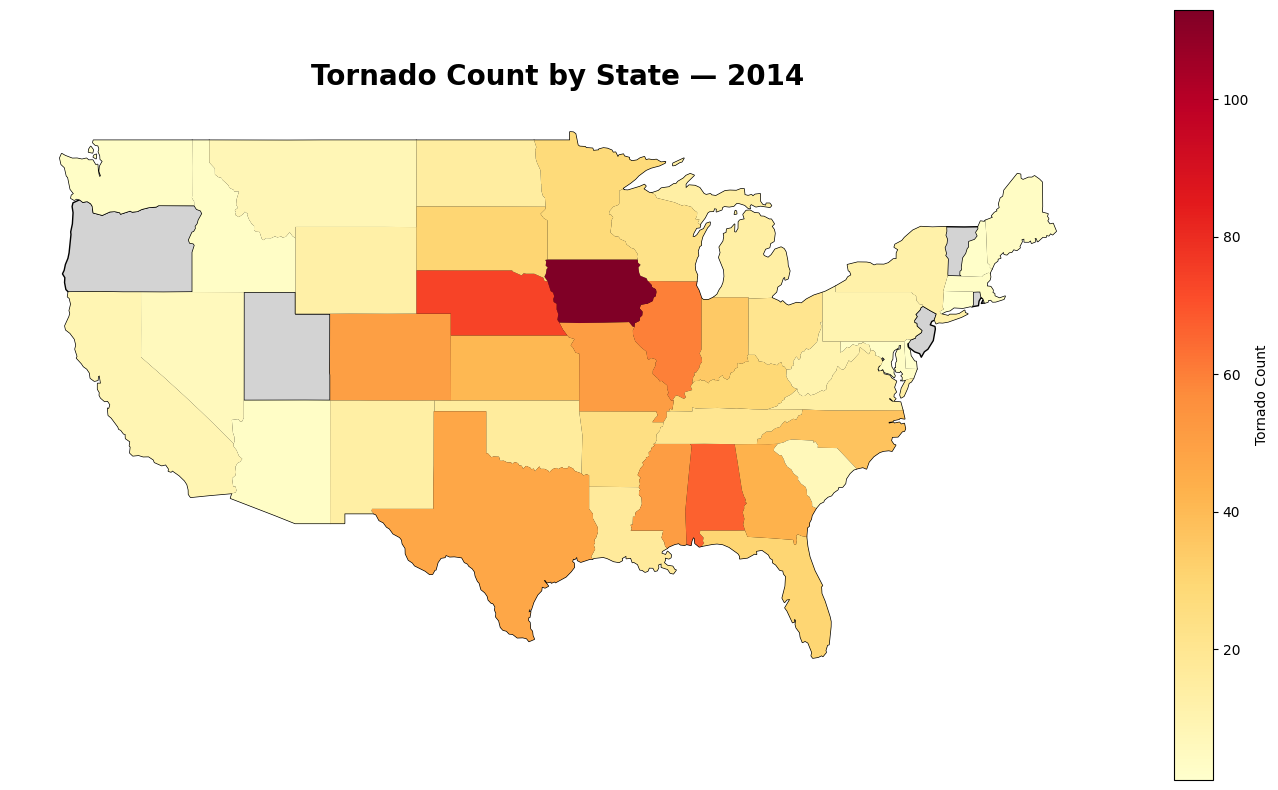

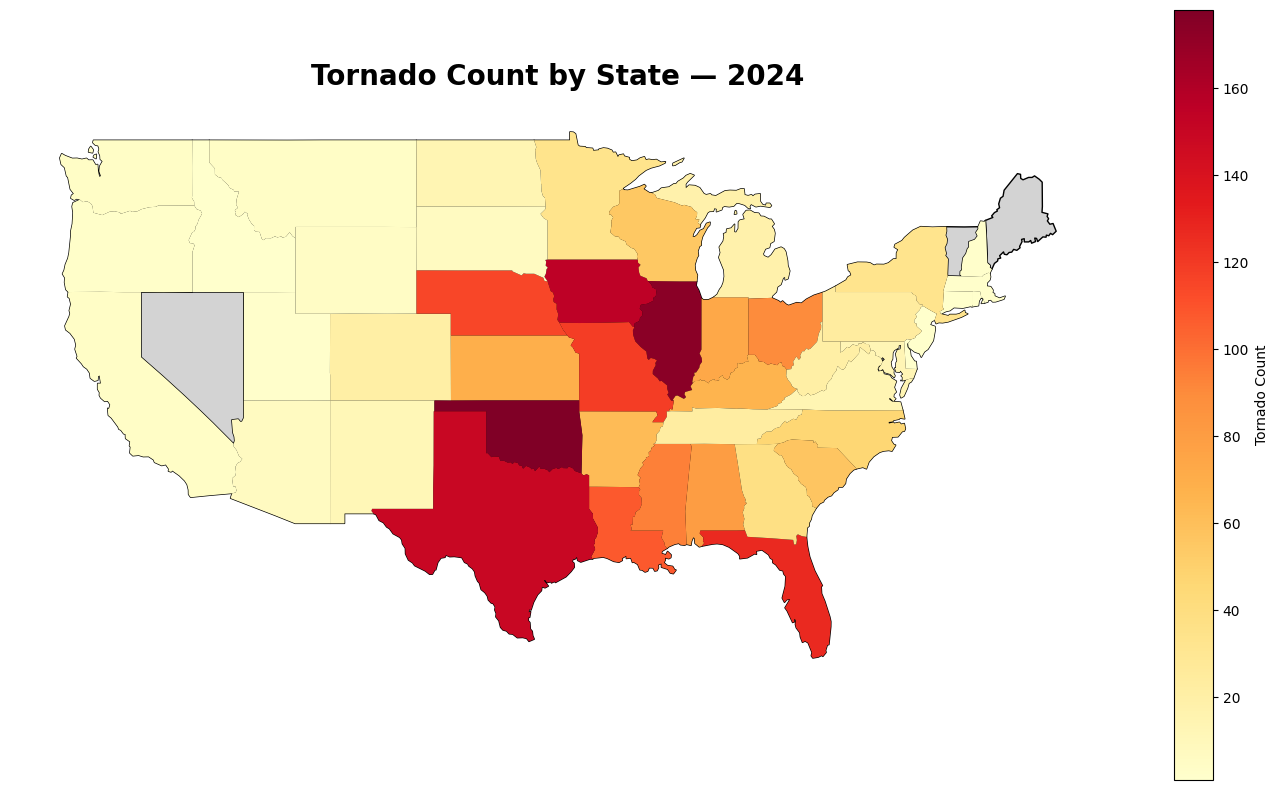

In [ ]:
# Query tornado counts by state. We SELECT FROM tornado events table, and join the STATE table.
map_df = pd.read_sql("""
    SELECT t.state, t.year, COUNT(*) as tornado_count, 
           AVG(t.tor_length) as avg_length,
           s.region_name
    FROM tornado_events t
    JOIN state_regions s ON t.state = s.state
    GROUP BY t.state, t.year
""", conn)

# Need to convert abbreviations back to full names to match GeoJSON. 
state_names = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming'
}

map_df['state_name'] = map_df['state'].map(state_names)

# Merge with GeoDataFrame 
merged = continental.merge(map_df, left_on='name', right_on='state_name', how='left')

# Plot one year at a time using a for loop.
for year in [2004, 2014, 2024]:
    year_data = merged[merged['year'] == year]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    continental.plot(ax=ax, color='lightgrey', edgecolor='black')
    year_data.plot(
        column='tornado_count',
        ax=ax,
        cmap='YlOrRd',
        legend=True,
        legend_kwds={'label': 'Tornado Count'}
    )
    plt.title(f'Tornado Count by State — {year}', fontsize=20, fontweight='bold', pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'../Graphs/tornado_map_{year}.png', bbox_inches='tight', dpi=300)
    plt.show()

## <span style="color: aqua;">🌪️ Conclusion</span>

Is Tornado Alley shifting eastward? While it may be tempting to say so, the data suggests 
something more nuanced: growth rather than a shift. This aligns with what the meteorological 
community calls "Dixie Alley" — what this analysis refers to as the "Emerging States." 

**Tornado Alley isn't moving; it's expanding.** Tornadoes across the continental United States 
are increasing in both frequency and strength, with wider paths and greater areas of impact. 
B